In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

## Qunatization Process
### Quantization is a compression technique that converts a model's high-precision weights (usually 32-bit or 16-bit floats) into lower-precision formats like 8-bit or 4-bit integers.
### It helps to reduce the model weights space to low size such that on single hardware(gpu) we can run it

### Int8 - Qunatization

In [ ]:
X = np.linspace(-1.0,1.0,100)

In [ ]:
X[:10]

array([-1.        , -0.97979798, -0.95959596, -0.93939394, -0.91919192,
       -0.8989899 , -0.87878788, -0.85858586, -0.83838384, -0.81818182])

In [ ]:
x_min = -1.0
x_max = 1.0
q_min = -128
q_max = 127

scale = (x_max - x_min) / (q_max - q_min)
scale

0.00784313725490196

In [ ]:
# zero_point
zero_point = 0.0

# quantization floast -> int8
q = np.round((X - zero_point)/scale).astype(int)
q  = np.clip(q,q_min,q_max) # to take the value between that range only
q

array([-128, -125, -122, -120, -117, -115, -112, -109, -107, -104, -102,
        -99,  -97,  -94,  -91,  -89,  -86,  -84,  -81,  -79,  -76,  -73,
        -71,  -68,  -66,  -63,  -61,  -58,  -55,  -53,  -50,  -48,  -45,
        -42,  -40,  -37,  -35,  -32,  -30,  -27,  -24,  -22,  -19,  -17,
        -14,  -12,   -9,   -6,   -4,   -1,    1,    4,    6,    9,   12,
         14,   17,   19,   22,   24,   27,   30,   32,   35,   37,   40,
         43,   45,   48,   50,   53,   55,   58,   61,   63,   66,   68,
         71,   73,   76,   79,   81,   84,   86,   89,   91,   94,   97,
         99,  102,  104,  107,  109,  112,  115,  117,  120,  122,  125,
        127])

In [ ]:
# Dequantization int8 -> float
x = scale * ( q- zero_point)
x # some drop in precision

array([-1.00392157, -0.98039216, -0.95686275, -0.94117647, -0.91764706,
       -0.90196078, -0.87843137, -0.85490196, -0.83921569, -0.81568627,
       -0.8       , -0.77647059, -0.76078431, -0.7372549 , -0.71372549,
       -0.69803922, -0.6745098 , -0.65882353, -0.63529412, -0.61960784,
       -0.59607843, -0.57254902, -0.55686275, -0.53333333, -0.51764706,
       -0.49411765, -0.47843137, -0.45490196, -0.43137255, -0.41568627,
       -0.39215686, -0.37647059, -0.35294118, -0.32941176, -0.31372549,
       -0.29019608, -0.2745098 , -0.25098039, -0.23529412, -0.21176471,
       -0.18823529, -0.17254902, -0.14901961, -0.13333333, -0.10980392,
       -0.09411765, -0.07058824, -0.04705882, -0.03137255, -0.00784314,
        0.00784314,  0.03137255,  0.04705882,  0.07058824,  0.09411765,
        0.10980392,  0.13333333,  0.14901961,  0.17254902,  0.18823529,
        0.21176471,  0.23529412,  0.25098039,  0.2745098 ,  0.29019608,
        0.31372549,  0.3372549 ,  0.35294118,  0.37647059,  0.39

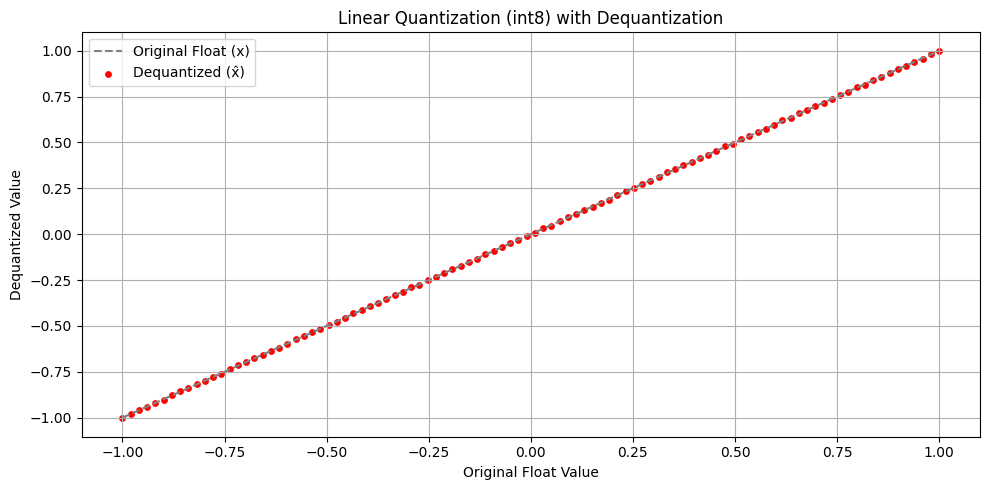

In [ ]:
# Plot original vs. dequantized
plt.figure(figsize=(10, 5))
plt.plot(X, X, label='Original Float (x)', linestyle='--', color='gray')
plt.scatter(X, x, label='Dequantized (x̂)', color='red', s=15)
plt.title('Linear Quantization (int8) with Dequantization')
plt.xlabel('Original Float Value')
plt.ylabel('Dequantized Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## NF4 Quantization
### So here the quantizations bins are created by considering the percentage of values in that range

In [ ]:
nf4_values = np.array([
    -1.0, -0.75, -0.5, -0.35, -0.2, -0.1, -0.05, -0.01,
     0.01,  0.05,  0.1,  0.2,  0.35,  0.5,  0.75,  1.0
])  ## this are the nearest low precision values from given range (float 4) ie 16 nf4 float representating values

# Step 2: Simulate original float values
x = np.linspace(-1.0, 1.0, 100)
x[:10]  # high precision float value

array([-1.        , -0.97979798, -0.95959596, -0.93939394, -0.91919192,
       -0.8989899 , -0.87878788, -0.85858586, -0.83838384, -0.81818182])

<Axes: ylabel='Count'>

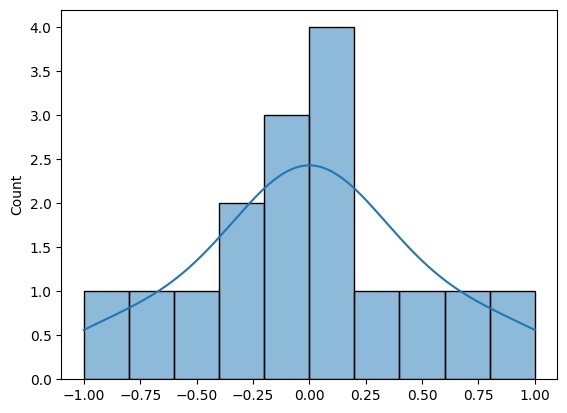

In [ ]:
import seaborn as sns
sns.histplot(nf4_values,kde=True,bins=10) # normal distribution

In [ ]:
def quantize_to_nf4(x_vals, nf4_lut):
    indices = np.argmin(np.abs(x_vals[:, None] - nf4_lut[None, :]), axis=1)
    return nf4_lut[indices]
## this function takes the high precision values (x_vals) and their float4 representation value (nf4_lut) and for each value in x_val it finds out the neareset value in the i.e for each value in x_val 16 values assigned then we take
## the argmin to get the minimum distance value from any of the point and that is remaped
## the difference is taken to get the closet distance between points

In [ ]:
x_vals = x
nf4_lut = nf4_values

In [ ]:
x_vals[:, None] - nf4_lut[None, :]

array([[ 0.        , -0.25      , -0.5       , ..., -1.5       ,
        -1.75      , -2.        ],
       [ 0.02020202, -0.22979798, -0.47979798, ..., -1.47979798,
        -1.72979798, -1.97979798],
       [ 0.04040404, -0.20959596, -0.45959596, ..., -1.45959596,
        -1.70959596, -1.95959596],
       ...,
       [ 1.95959596,  1.70959596,  1.45959596, ...,  0.45959596,
         0.20959596, -0.04040404],
       [ 1.97979798,  1.72979798,  1.47979798, ...,  0.47979798,
         0.22979798, -0.02020202],
       [ 2.        ,  1.75      ,  1.5       , ...,  0.5       ,
         0.25      ,  0.        ]])

In [ ]:
nf4_values[np.argmin(np.abs((x_vals[:,None] - nf4_lut[None, :])),axis=1)]

array([-1.  , -1.  , -1.  , -1.  , -1.  , -1.  , -1.  , -0.75, -0.75,
       -0.75, -0.75, -0.75, -0.75, -0.75, -0.75, -0.75, -0.75, -0.75,
       -0.75, -0.5 , -0.5 , -0.5 , -0.5 , -0.5 , -0.5 , -0.5 , -0.5 ,
       -0.5 , -0.5 , -0.35, -0.35, -0.35, -0.35, -0.35, -0.35, -0.35,
       -0.2 , -0.2 , -0.2 , -0.2 , -0.2 , -0.2 , -0.2 , -0.1 , -0.1 ,
       -0.1 , -0.05, -0.05, -0.05, -0.01,  0.01,  0.05,  0.05,  0.05,
        0.1 ,  0.1 ,  0.1 ,  0.2 ,  0.2 ,  0.2 ,  0.2 ,  0.2 ,  0.2 ,
        0.2 ,  0.35,  0.35,  0.35,  0.35,  0.35,  0.35,  0.35,  0.5 ,
        0.5 ,  0.5 ,  0.5 ,  0.5 ,  0.5 ,  0.5 ,  0.5 ,  0.5 ,  0.5 ,
        0.75,  0.75,  0.75,  0.75,  0.75,  0.75,  0.75,  0.75,  0.75,
        0.75,  0.75,  0.75,  1.  ,  1.  ,  1.  ,  1.  ,  1.  ,  1.  ,
        1.  ])

In [ ]:
x_nf4 = quantize_to_nf4(x, nf4_values)
x_nf4[:10]

array([-1.  , -1.  , -1.  , -1.  , -1.  , -1.  , -1.  , -0.75, -0.75,
       -0.75])

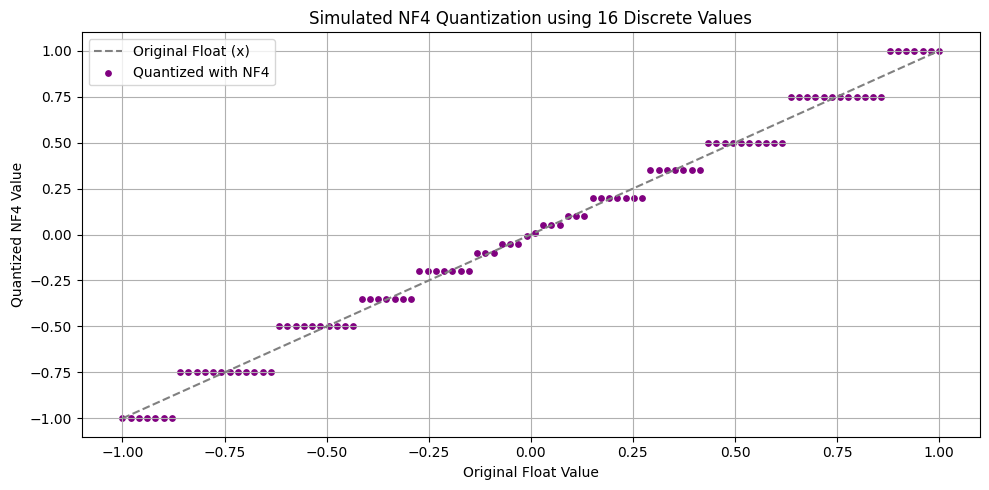

In [ ]:
# Step 4: Plot original vs. quantized (NF4)
plt.figure(figsize=(10, 5))
plt.plot(x, x, label='Original Float (x)', linestyle='--', color='gray')
plt.scatter(x, x_nf4, label='Quantized with NF4', color='purple', s=15)
plt.title('Simulated NF4 Quantization using 16 Discrete Values')
plt.xlabel('Original Float Value')
plt.ylabel('Quantized NF4 Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()